<a href="https://colab.research.google.com/github/tatyanakrivonogova/machine-learning-methods/blob/master/%D0%91%D0%BB%D0%BE%D0%BA_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Метод главных компонент (PCA)
Метод главных компонент (PCA) – техника снижения размерности, которая линейно преобразует исходные признаки в новое пространство меньшей размерности, максимизируя дисперсию данных.

### Используемые библиотеки

In [168]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Датасет

In [169]:
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

print("Размер:", X.shape)
print("Целевые классы:", target_names)
print("\nПервые 5 строк данных:\n", pd.DataFrame(X, columns=feature_names).head())

Размер: (178, 13)
Целевые классы: ['class_0' 'class_1' 'class_2']

Первые 5 строк данных:
    alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.8

### Предварительная обработка датасета

In [170]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Тепловая карта

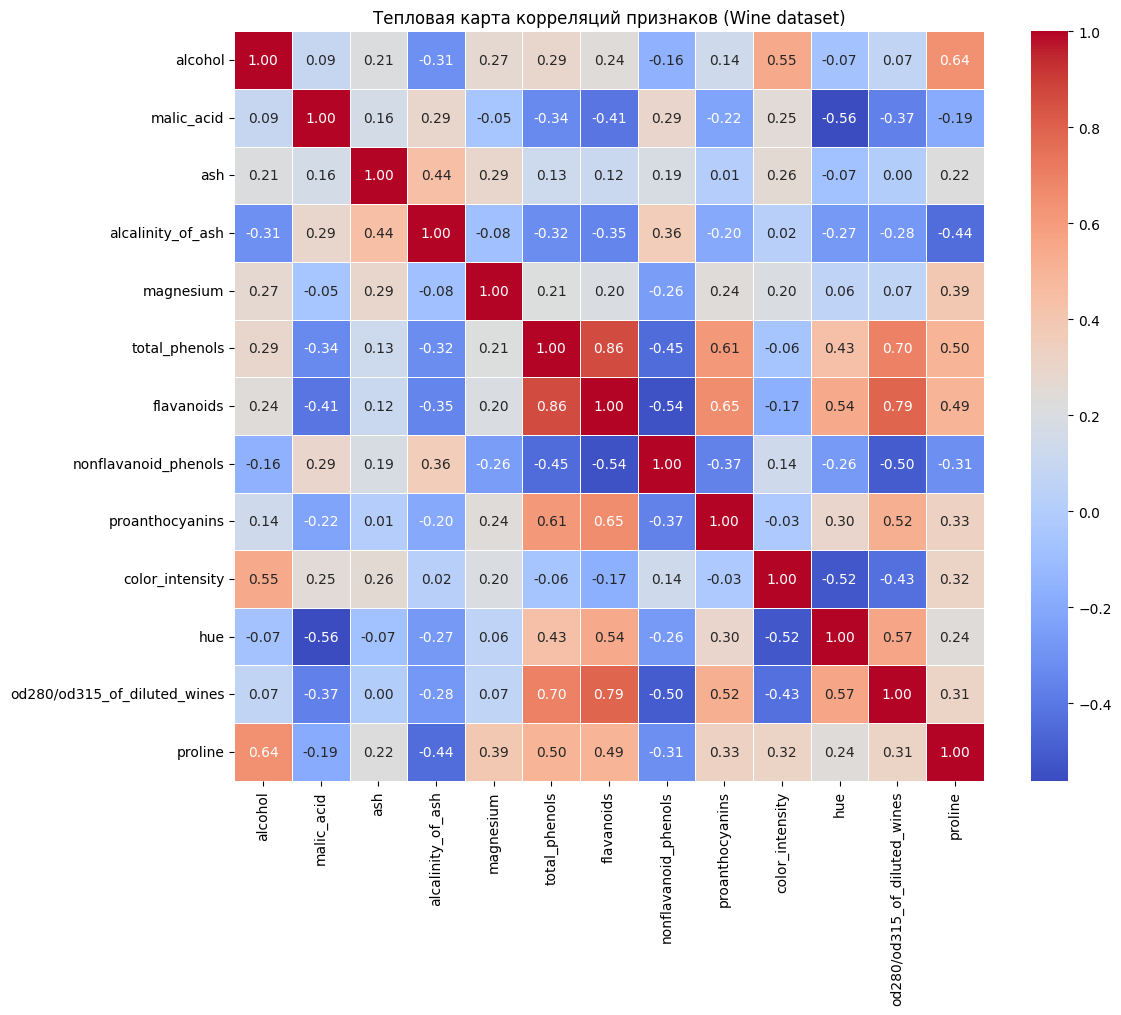

In [171]:
plt.figure(figsize=(12, 10))
corr_matrix = np.corrcoef(X_scaled.T)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=feature_names, yticklabels=feature_names,
            square=True, linewidths=0.5)
plt.title('Тепловая карта корреляций признаков (Wine dataset)')
plt.tight_layout()
plt.show()

### Обучение модели

In [172]:
pca = PCA(n_components=2)
pca.fit(X_scaled)

PCA(n_components=2)

### Прогнозы модели

In [173]:
X_pca = pca.transform(X_scaled)
print("Размерность после PCA:", X_pca.shape)
print("\nПервые 5 образцов в пространстве главных компонент:\n", X_pca[:5])

Размерность после PCA: (178, 2)

Первые 5 образцов в пространстве главных компонент:
 [[ 3.31675081  1.44346263]
 [ 2.20946492 -0.33339289]
 [ 2.51674015  1.0311513 ]
 [ 3.75706561  2.75637191]
 [ 1.00890849  0.86983082]]


### Графики выходных результатов

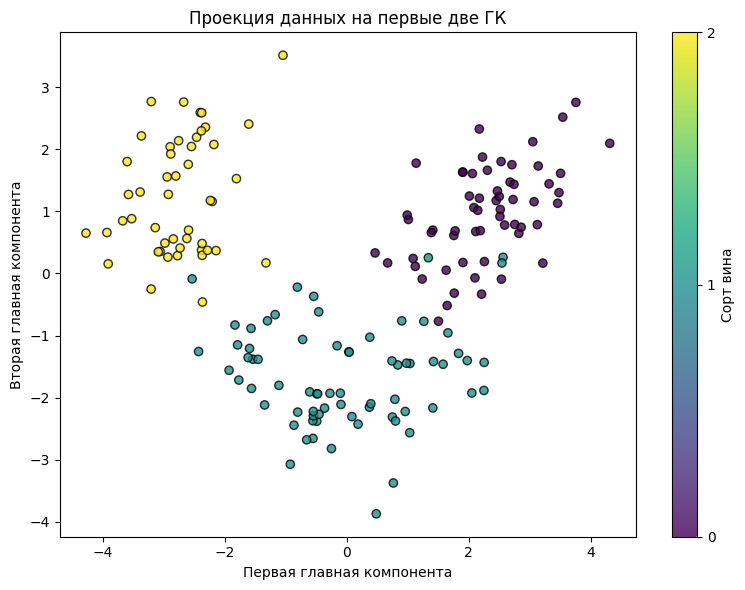

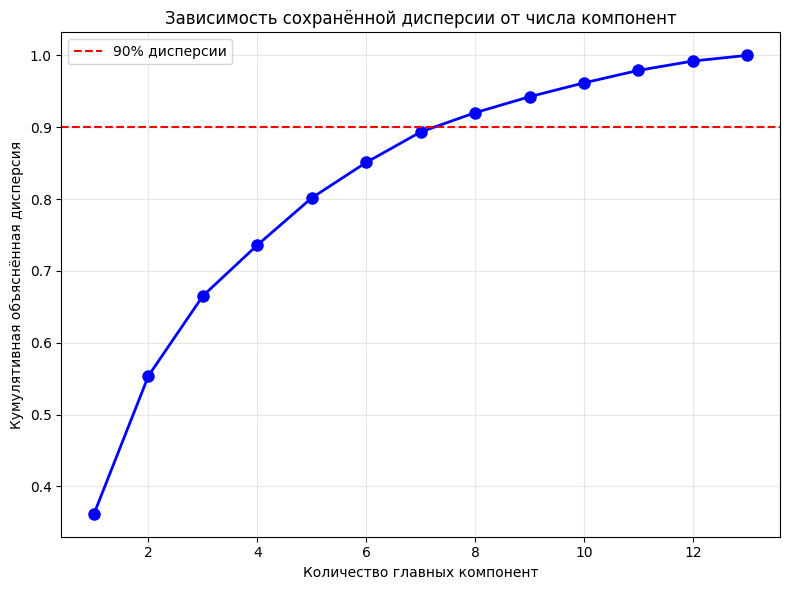

In [174]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.8)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Проекция данных на первые две ГК')
plt.colorbar(scatter, ticks=range(len(target_names)), label='Сорт вина')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
pca_full = PCA()
pca_full.fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% дисперсии')
plt.xlabel('Количество главных компонент')
plt.ylabel('Кумулятивная объяснённая дисперсия')
plt.title('Зависимость сохранённой дисперсии от числа компонент')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Исходные признаки
Accuracy:  0.7407
Precision: 0.7409
Recall:    0.7407
F1-score:  0.7361
              precision    recall  f1-score   support

     class_0       0.69      0.61      0.65        18
     class_1       0.79      0.71      0.75        21
     class_2       0.74      0.93      0.82        15

    accuracy                           0.74        54
   macro avg       0.74      0.75      0.74        54
weighted avg       0.74      0.74      0.74        54


PCA (n_components=2, объяснённая дисперсия=0.549)
Accuracy:  0.9074
Precision: 0.9110
Recall:    0.9074
F1-score:  0.9061
              precision    recall  f1-score   support

     class_0       0.85      0.94      0.89        18
     class_1       0.94      0.81      0.87        21
     class_2       0.94      1.00      0.97        15

    accuracy                           0.91        54
   macro avg       0.91      0.92      0.91        54
weighted avg       0.91      0.91      0.91        54


PCA (n_components=8, об

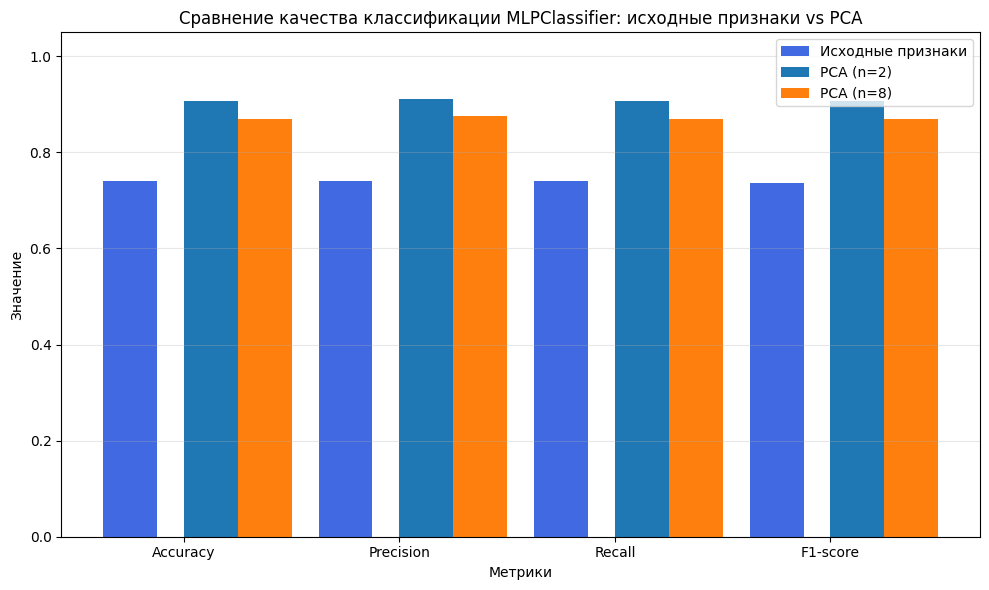

In [175]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def evaluate_mlp(X_train_data, X_test_data, y_train_data, y_test_data, description):
    mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42, early_stopping=True)
    mlp.fit(X_train_data, y_train_data)
    y_pred = mlp.predict(X_test_data)

    acc = accuracy_score(y_test_data, y_pred)
    prec = precision_score(y_test_data, y_pred, average='weighted')
    rec = recall_score(y_test_data, y_pred, average='weighted')
    f1 = f1_score(y_test_data, y_pred, average='weighted')

    print(f"\n{description}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(classification_report(y_test_data, y_pred, target_names=target_names))

    return acc, prec, rec, f1

# Оценка на исходных (масштабированных) признаках
orig_metrics = evaluate_mlp(X_train_scaled, X_test_scaled, y_train, y_test,
                            "Исходные признаки")

# Оценка для двух вариантов: 2 компоненты и оптимальное для 90% дисперсии - 8 компонент
components_list = [2, 8]
results = {}

for n_comp in components_list:
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    explained_var = pca.explained_variance_ratio_.sum()
    metrics = evaluate_mlp(X_train_pca, X_test_pca, y_train, y_test,
                           f"PCA (n_components={n_comp}, объяснённая дисперсия={explained_var:.3f})")
    results[n_comp] = {'metrics': metrics, 'explained_var': explained_var}

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
orig_vals = orig_metrics
x = np.arange(len(metrics_names))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, orig_vals, width, label='Исходные признаки', color='royalblue')

for i, (n_comp, data) in enumerate(results.items()):
    comp_vals = data['metrics']
    offset = (i + 1) * width - width/2
    plt.bar(x + offset, comp_vals, width, label=f'PCA (n={n_comp})')

plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.title('Сравнение качества классификации MLPClassifier: исходные признаки vs PCA')
plt.xticks(x, metrics_names)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()